## 0. Setup

In [1]:
import sys
import os
from pathlib import Path
# Add project root to path (works for both local and Colab)
project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import torch
from itertools import islice
from torch.utils.data import Dataset, DataLoader
from src.models.spare_autoencoder import SparseAutoEncoder
from src.training.dataset_creator import ChunkIterableGenerator, split_files
from src.training.losses import compute_loss
from src.training.trainer import SAETrainer
from typing import Optional, Callable
import pandas as pd
import matplotlib.pyplot as plt
import wandb


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA build:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: False
Torch CUDA build: None


In [ ]:
# Hyperparameters:
hyperparameters = {
    "num_epochs": 10,
    "expansion_factor": 4,
    "batch_size": 32,
    "num_workers": 0,
    "lr": 1e-4,
    "log_frequency": 1
}


In [ ]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="adityaiyer-m-self",
    # Set the wandb project where this run will be logged.
    project="sae-for-monosemanticity",
    # Track hyperparameters and run metadata.
    config=hyperparameters,
)

In [5]:
MODEL_SAVE_PATH = project_root / 'model_weights.pth'

## 1. Load data

In [6]:
activation_chunk_dir = str(project_root / 'data' / 'gpt2_activation_chunks')
train_files, val_files, test_files = split_files(activation_chunk_dir)

print(f"Number of Training Files: {len(train_files)}")
print(f"Number of Validation Files: {len(val_files)}")
print(f"Number of Testing Files: {len(test_files)}")

Number of Training Files: 40
Number of Validation Files: 5
Number of Testing Files: 5


In [7]:
train_chunk_generator = ChunkIterableGenerator(train_files)
val_chunk_generator = ChunkIterableGenerator(val_files)
test_chunk_generator = ChunkIterableGenerator(test_files)

In [8]:
training_dataloader = torch.utils.data.DataLoader(train_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])
val_dataloader = torch.utils.data.DataLoader(val_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])
test_dataloader = torch.utils.data.DataLoader(test_chunk_generator, batch_size=hyperparameters["batch_size"], num_workers=hyperparameters["num_workers"])


## 2. Define Model

In [9]:
model = SparseAutoEncoder(d_model=768, expansion_factor=hyperparameters["expansion_factor"])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

## 3. Training

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters["lr"])
loss_fn = compute_loss

In [ ]:
TRAIN_MODEL = True  # Set to False to skip training and load saved weights

trainer = SAETrainer(
    model=model,
    dataloader=training_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

if TRAIN_MODEL:
    trainer.train(
        num_epochs=hyperparameters["num_epochs"],
        log_every=hyperparameters["log_frequency"],
    )
else:
    if not os.path.exists(MODEL_SAVE_PATH):
        raise FileNotFoundError(
            f"No saved weights found at {MODEL_SAVE_PATH}. "
            "Set TRAIN_MODEL = True to train from scratch."
        )
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f"Loaded model weights from {MODEL_SAVE_PATH}. Skipping training.")

Loaded model weights from /Users/adityaiyer/Desktop/Projects/sae-monosemantic/model_weights.pth. Skipping training.


In [ ]:
run.log({
    "training_loss_curve": wandb.plot.line_series(
        xs=list(range(len(trainer.training_losses))),
        ys=[trainer.training_losses],
        keys=["Training Loss"],
        title="Training Loss",
        xname="Step"
    )
})

## 4. Visualize Training Loss

In [ ]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trainer.training_losses, color='#2e86ab', linewidth=0.8, alpha=0.9, label='Training loss')

# Optionally smooth the training curve for readability (rolling mean)
if len(trainer.training_losses) > 50:
    window = min(50, len(trainer.training_losses) // 10)
    smoothed = pd.Series(trainer.training_losses).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#e94f37', linewidth=2, label=f'Training smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Training Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# intermediate save
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f" model weights saved to {MODEL_SAVE_PATH}")

## 5. Validation

In [12]:
validation_loss, validation_num_batches =  trainer.evaluate(val_dataloader)

Loading chunk file: /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_5.pt
activations and token_ids extracted
Finished processing /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_5.pt
Loading chunk file: /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_6.pt
activations and token_ids extracted
Finished processing /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_6.pt
Loading chunk file: /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_8.pt
activations and token_ids extracted
Finished processing /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_8.pt
Loading chunk file: /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/gpt2_activation_chunks/chunk_14.pt
activations and token_ids extracted
Finished processing /Users/adityaiyer/Desktop/Projects/sae-monosemantic/data/g

In [ ]:
run.log({
    "validation_loss_curve": wandb.plot.line_series(
        xs=list(range(len(validation_loss))),
        ys=[validation_loss],
        keys=["Validation Loss"],
        title="Validation Loss",
        xname="Step"
    )
})

## 6. Visualize Validation Loss

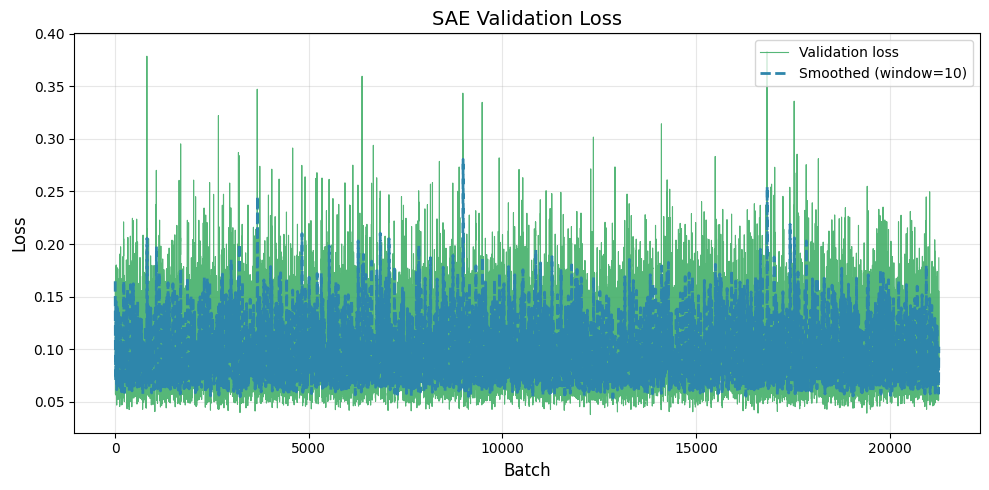

In [13]:
# Plot validation loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(validation_loss, color='#44af69', linewidth=0.8, alpha=0.9, label='Validation loss')

# Optionally smooth the curve for readability (rolling mean)
if len(validation_loss) > 10:
    window = min(10, len(validation_loss) // 5)
    smoothed = pd.Series(validation_loss).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#2e86ab', linewidth=2, linestyle='--', label=f'Smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Validation Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save Model

In [ ]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f" model weights saved to {MODEL_SAVE_PATH}")

## 8. Test Model

In [ ]:
test_loss, test_num_batches = trainer.evaluate(test_dataloader)

In [ ]:
run.log({
    "test_loss_curve": wandb.plot.line_series(
        xs=list(range(len(test_loss))),
        ys=[test_loss],
        keys=["Test Loss"],
        title="Test Loss",
        xname="Step"
    )
})

## 9. Visualize Test Loss

In [ ]:
# Plot test loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_loss, color='#f4a261', linewidth=0.8, alpha=0.9, label='Test loss')

# Optionally smooth the curve for readability (rolling mean)
if len(test_loss) > 10:
    window = min(10, len(test_loss) // 5)
    smoothed = pd.Series(test_loss).rolling(window=window, min_periods=1).mean()
    ax.plot(smoothed.values, color='#e76f51', linewidth=2, linestyle='--', label=f'Smoothed (window={window})')

ax.set_xlabel('Batch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('SAE Test Loss', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()